# Setup


In [1]:
# Load packages.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
from torch.utils.data import DataLoader, TensorDataset

import utils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Rebuild the validation data

This reproduces the preprocessing and region-level split used by `many_RBP_prototype.ipynb`, so the notebook works from a fresh kernel.


In [2]:
INPUT_DIR = "/tscc/lustre/ddn/scratch/kflanagan/plip_plop_results/ml_inputs"
COMPARISON_TABLE = (
    "/tscc/nfs/home/kflanagan/projects/plip_plop/"
    "machine_learning_prototype/encode_initial_30_comparisons.tsv"
)
MODEL_PATH = (
    "/tscc/nfs/home/kflanagan/scratch/plip_plop_results/"
    "many_IN_RBP_baseline.pt"
)

comparison_table = pd.read_csv(COMPARISON_TABLE, sep="\t")

expected_files = [
    os.path.join(INPUT_DIR, f"{row.experiment_A}_{row.experiment_B}.npz")
    for row in comparison_table.itertuples(index=False)
]
missing_files = [path for path in expected_files if not os.path.exists(path)]

if missing_files:
    preview = "\n".join(missing_files[:5])
    raise FileNotFoundError(
        f"Missing {len(missing_files)} expected input file(s). First missing file(s):\n{preview}"
    )

print(f"Found all {len(expected_files)} comparison files.")


Found all 30 comparison files.


In [3]:
all_signals = []
all_metadata = []

for comparison_id, row in comparison_table.iterrows():
    experiment_A = row["experiment_A"]
    experiment_B = row["experiment_B"]
    npz_file = os.path.join(INPUT_DIR, f"{experiment_A}_{experiment_B}.npz")

    with np.load(npz_file) as data:
        raw_signals = data["signals"].astype(np.float32)

        # Preserve raw signal summaries for interpreting PCA extremes.
        channel_totals = raw_signals.sum(axis=2)
        total_signal = channel_totals.sum(axis=1)

        # Match the training preprocessing: log transform, then independently
        # L2-normalize each RBP channel within each 300-position window.
        comparison_signals = np.log1p(raw_signals)
        channel_norms = np.sqrt(
            (comparison_signals ** 2).sum(axis=2, keepdims=True)
        )
        comparison_signals = np.divide(
            comparison_signals,
            channel_norms,
            out=np.zeros_like(comparison_signals),
            where=channel_norms > 0,
        )

        all_signals.append(comparison_signals)
        all_metadata.append(pd.DataFrame({
            "comparison_id": comparison_id,
            "category": row["category"],
            "experiment_A": experiment_A,
            "experiment_B": experiment_B,
            "chrom": data["chrom"],
            "start": data["start"],
            "end": data["end"],
            "strand": data["strand"],
            "region_id": data["region_id"],
            "block_number": data["block_number"],
            "signal_A": channel_totals[:, 0],
            "signal_B": channel_totals[:, 1],
            "total_signal": total_signal,
        }))

signals = np.concatenate(all_signals, axis=0)
metadata = pd.concat(all_metadata, ignore_index=True)

print("Signal shape:", signals.shape)
print("Metadata shape:", metadata.shape)
print("Comparisons:", metadata["comparison_id"].nunique())


/scratch/kflanagan/job_12086704/ipykernel_839046/2229899813.py:18: RuntimeWarning: invalid value encountered in log1p
  comparison_signals = np.log1p(raw_signals)


Signal shape: (717750, 2, 300)
Metadata shape: (717750, 13)
Comparisons: 30


In [4]:
# Reproduce the training weights retained in the PCA metadata.
alpha = 0.5
comparison_counts = metadata.groupby("comparison_id").size()
comparison_weight = comparison_counts ** (alpha - 1)

metadata["comparison_weight"] = metadata["comparison_id"].map(comparison_weight)
metadata["signal_weight"] = np.log1p(metadata["total_signal"])
metadata["signal_weight"] /= metadata.groupby("comparison_id")[
    "signal_weight"
].transform("mean")
metadata["weight"] = metadata["comparison_weight"] * metadata["signal_weight"]

# Split whole merged regions, never individual neighboring blocks.
metadata["region_key"] = (
    metadata["comparison_id"].astype(str)
    + "_"
    + metadata["region_id"].astype(str)
)

rng = np.random.default_rng(42)
val_mask = np.zeros(len(metadata), dtype=bool)

for comparison_id in metadata["comparison_id"].unique():
    comparison_rows = metadata["comparison_id"] == comparison_id
    comparison_regions = metadata.loc[
        comparison_rows, "region_key"
    ].drop_duplicates().to_numpy(dtype=object, copy=True)
    rng.shuffle(comparison_regions)

    split = int(len(comparison_regions) * 0.8)
    val_regions = comparison_regions[split:]
    val_mask |= metadata["region_key"].isin(val_regions).to_numpy()

val_signals = signals[val_mask]
val_metadata = metadata.loc[val_mask].reset_index(drop=True)
val_weights = val_metadata["weight"].to_numpy(dtype=np.float32)

val_dataset = TensorDataset(
    torch.from_numpy(val_signals),
    torch.from_numpy(val_weights),
)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

print("Validation windows:", len(val_dataset))
print("Validation comparisons:", val_metadata["comparison_id"].nunique())


/tscc/nfs/home/kflanagan/miniconda3/envs/ml_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Validation windows: 143119
Validation comparisons: 30


## Load the trained model


In [5]:
model = utils.SimpleAutoencoder(latent_dim=64).to(device)
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()
print("Loaded model:", MODEL_PATH)


Loaded model: /tscc/nfs/home/kflanagan/scratch/plip_plop_results/many_IN_RBP_baseline.pt


# Clustering/PCA

## Window-level PCA

In [6]:
pca, pca_df, latent_vectors, validation_signals = utils.build_validation_pca(
    model, val_loader, val_metadata, device
)

print("Window latent vectors:", latent_vectors.shape)
print("PC1 + PC2 explained variance:", pca.explained_variance_ratio_.sum())


Window latent vectors: (143119, 64)
PC1 + PC2 explained variance: 0.82674426


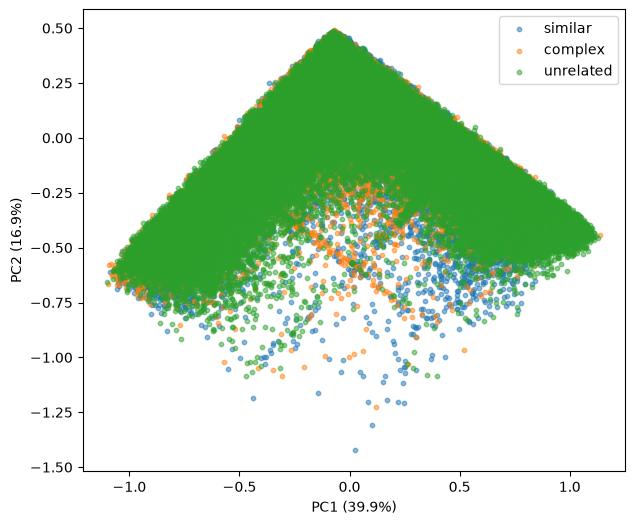

In [7]:
utils.plot_validation_pca(pca_df, pca)


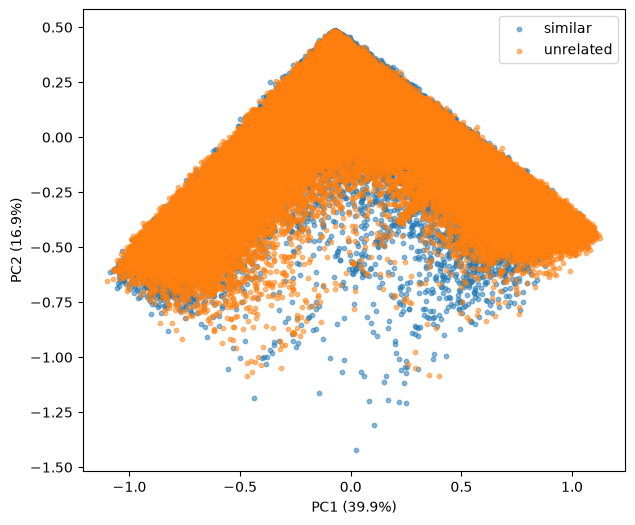

In [8]:
utils.plot_validation_pca(
    pca_df,
    pca,
    categories=["similar", "unrelated"],
)


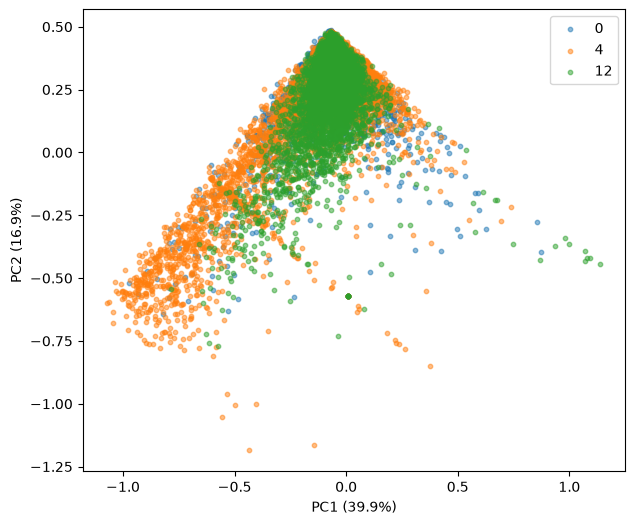

In [9]:
utils.plot_validation_pca(
    pca_df,
    pca,
    comparison_ids=[0, 4, 12],
    color_by="comparison_id",
)


## Mean latent vectors by comparison


In [10]:
comparison_latents, comparison_metadata = utils.build_comparison_latents(
    latent_vectors, val_metadata
)

print("Window latent vectors:", latent_vectors.shape)
print("Comparison latent vectors:", comparison_latents.shape)


Window latent vectors: (143119, 64)
Comparison latent vectors: (30, 64)


In [11]:
comparison_pca = PCA(n_components=2)
comparison_coords = comparison_pca.fit_transform(comparison_latents)

comparison_pca_df = comparison_metadata.copy()
comparison_pca_df["PC1"] = comparison_coords[:, 0]
comparison_pca_df["PC2"] = comparison_coords[:, 1]


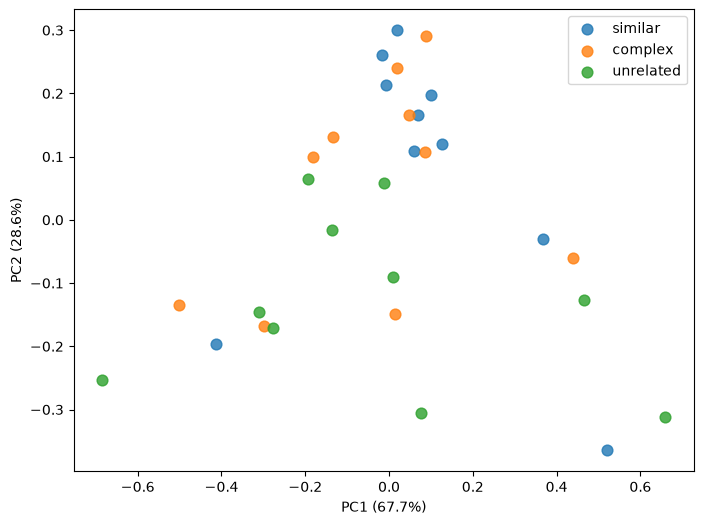

In [12]:
plt.figure(figsize=(8, 6))

for category, group in comparison_pca_df.groupby("category", sort=False):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=60,
        alpha=0.8,
        label=category,
    )

# Uncomment to label every comparison. It is informative but visually crowded.
# for _, row in comparison_pca_df.iterrows():
#     plt.annotate(row["pair_label"], (row["PC1"], row["PC2"]), fontsize=8)

plt.xlabel(f"PC1 ({comparison_pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({comparison_pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.legend()
plt.show()


## Inspect individual windows at PCA extremes

### PC1


In [13]:
pc1_order = pca_df["PC1"].sort_values().index
pc1_left = pc1_order[:5]
pc1_right = pc1_order[-5:]

print("Left side:", pc1_left)
print("Right side:", pc1_right)


Left side: Index([79336, 68316, 63973, 4806, 63975], dtype='int64')
Right side: Index([85744, 83802, 120196, 82949, 49515], dtype='int64')


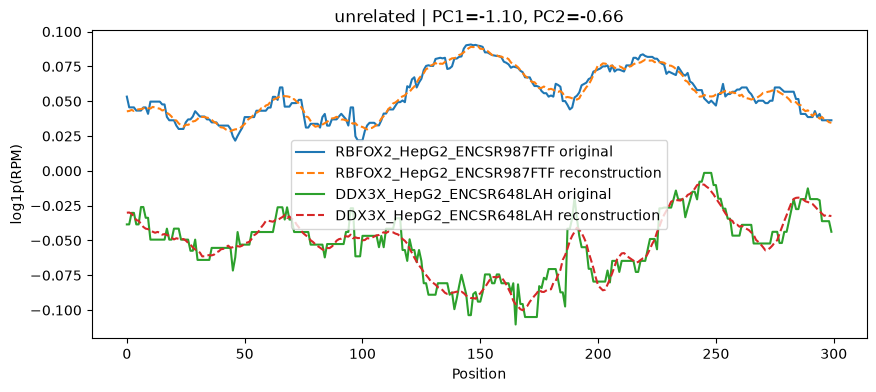

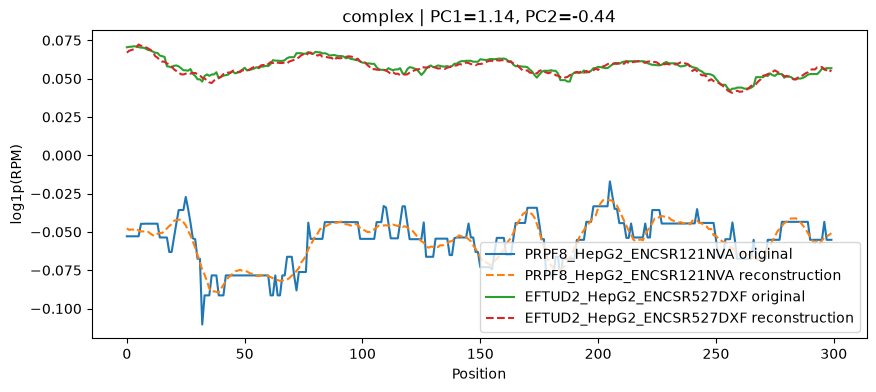

In [14]:
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc1_left[0]
)
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc1_right[-1]
)


### PC2


In [15]:
pc2_order = pca_df["PC2"].sort_values().index
pc2_bottom = pc2_order[:5]
pc2_top = pc2_order[-5:]

print("Bottom side:", pc2_bottom)
print("Top side:", pc2_top)


Bottom side: Index([41189, 41201, 57064, 39051, 40542], dtype='int64')
Top side: Index([43118, 41387, 42365, 42362, 43132], dtype='int64')


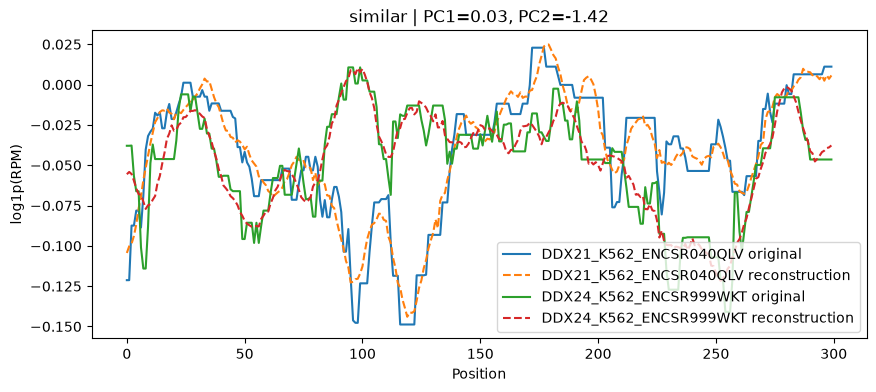

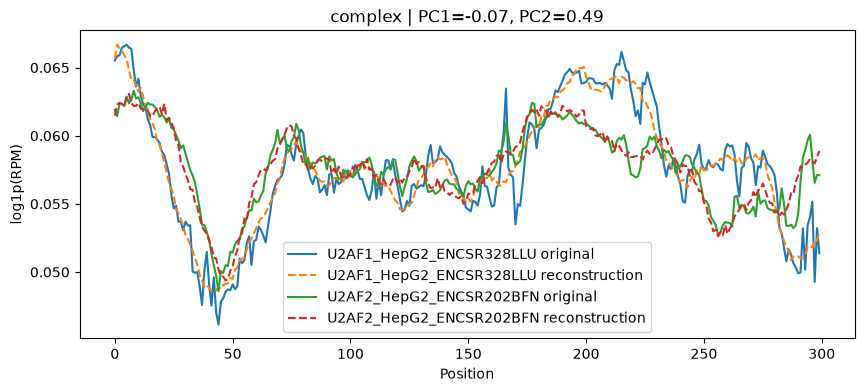

In [16]:
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc2_bottom[0]
)
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc2_top[-1]
)


### PC3

In [17]:
pc3_order = pca_df["PC3"].sort_values().index
pc3_bottom = pc3_order[:100]
pc3_top = pc3_order[-100:]

print("Bottom side:", pc3_bottom)
print("Top side:", pc3_top)


Bottom side: Index([ 96288,  76273,  61440, 136752,  22126,  71219,  52870,  93809, 136655,
        26748,  88909, 133058,  23114,  52853,  38878, 123294,  87285, 119087,
        40725, 134101, 121650, 133898, 121303,  40114, 128884, 121247, 126152,
       104594,  43187, 135719, 122930,   9274,  29280, 125515, 132350, 133672,
       132549,  46274, 124175, 138063, 118468, 122971,  73311, 126875,  41251,
       132902, 138732,  69585, 135722,  22283, 141621,  45434, 136651,  49207,
        65150,  64947,  60644,  69359,  60478,  47857,  27804, 117801, 120104,
       134612, 133609, 132922, 124126, 105890,  64973, 126432, 128683,  61608,
        68623,  30539, 132346,  36639,   7928,  69942,  61144,  67887, 131317,
       128155, 136038, 126292,  24456,   5210,  45102, 121386,   7620,  43371,
       126138,   8048,  58565,  88452, 117681,   6693, 135025, 136205,  68847,
        75258],
      dtype='int64')
Top side: Index([123425,   8447, 127339,  33399,  11674,  36343,  43192,  45365, 

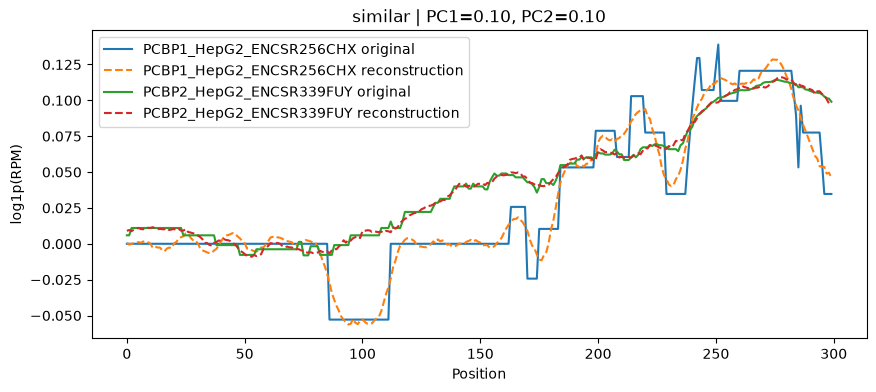

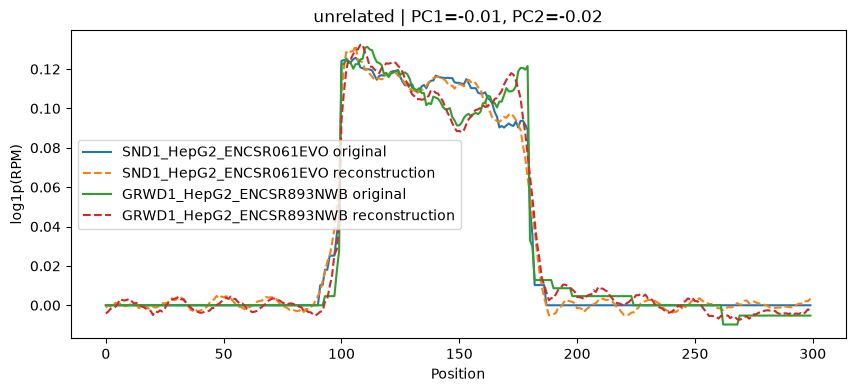

In [18]:
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc3_bottom[95]
)
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc3_top[-100]
)


### PC10

In [19]:
pc10_order = pca_df["PC10"].sort_values().index
pc10_bottom = pc10_order[:100]
pc10_top = pc10_order[-100:]

print("Bottom side:", pc10_bottom)
print("Top side:", pc10_top)


Bottom side: Index([ 52378,  56945,  91356,  59057, 131403, 117713,  43934,  97070,  10526,
         8628, 125522,  10416,  74473,  10542,  27988,  43720,   1003,  78225,
       106487,  80672,   6730,  11041,  45168,  44074,   9342, 114407,   6267,
         5829,  51418, 116964,  95115,  72901, 107754, 112599, 104083,  22188,
        92372,  11927,  34338,  43865,  23189,  44057,  61378,  29478,  73766,
        85481,  61576,  53716,  85238,  68105,  38906,   6920,  58586,  44508,
        83359, 133206,  20997, 113532,  45267,  90957, 127959,  96124,  52582,
       134112,  61633,  63775,  56475,  54931,  84210,  27283,  61257, 102711,
         7485,  58543, 114227,  47043,   8876,  51303, 130326, 116828,  89393,
        44974, 119344,  75363,  61032,  88704,  78602,  59466,  44839, 116535,
        97959,  97232, 103654,  30135,  44233,  60500,  67489, 119699,  76242,
        50002],
      dtype='int64')
Top side: Index([ 61164, 126173, 120414,  29795,   6911, 114644,  10640,  89498, 

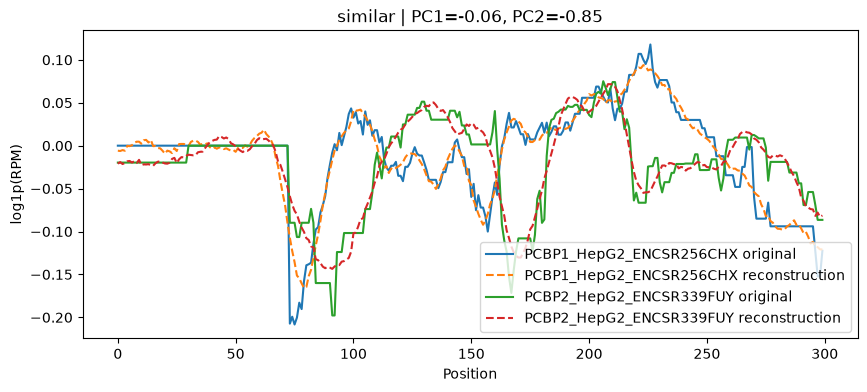

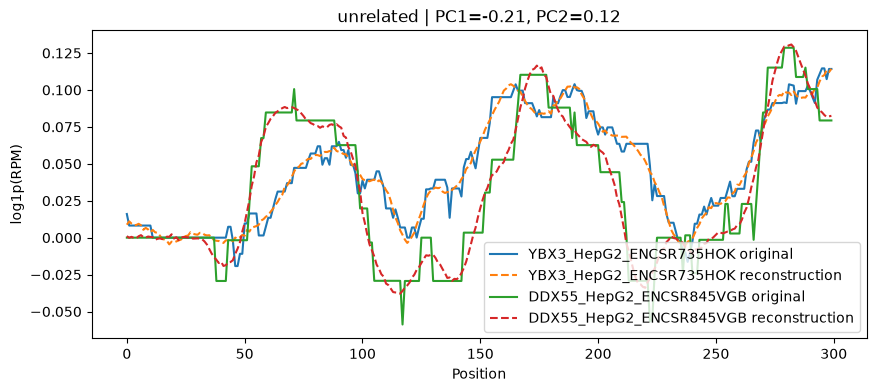

In [20]:
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc10_bottom[20]
)
utils.plot_window_reconstruction(
    validation_signals, model, pca_df, pc10_top[-1]
)


# Metric validation

In [21]:
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cosine

def calculate_window_diagnostics(validation_signals, center_start=125, center_end=175):
    diagnostics = []

    positions = np.arange(validation_signals.shape[2])

    for window in validation_signals:
        signal_A = window[0]
        signal_B = window[1]

        # Basic channel properties.
        sum_A = signal_A.sum()
        sum_B = signal_B.sum()

        # Correlation / similarity.
        if np.std(signal_A) == 0 or np.std(signal_B) == 0:
            pearson = 0
            spearman = 0
        else:
            pearson = pearsonr(signal_A, signal_B).statistic
            spearman = spearmanr(signal_A, signal_B).statistic

        if sum_A == 0 or sum_B == 0:
            cosine_sim = 0
        else:
            cosine_sim = 1 - cosine(signal_A, signal_B)

        mean_abs_difference = np.mean(np.abs(signal_A - signal_B))
        sum_abs_difference = np.sum(np.abs(signal_A - signal_B))

        # Peak positions.
        peak_A = np.argmax(signal_A) if sum_A > 0 else np.nan
        peak_B = np.argmax(signal_B) if sum_B > 0 else np.nan

        if np.isnan(peak_A) or np.isnan(peak_B):
            peak_distance = np.nan
        else:
            peak_distance = abs(peak_A - peak_B)

        # Center of mass.
        center_A = np.sum(positions * signal_A) / sum_A if sum_A > 0 else np.nan
        center_B = np.sum(positions * signal_B) / sum_B if sum_B > 0 else np.nan
        mean_center = np.nanmean([center_A, center_B])

        # Combine the two tracks for general spatial metrics.
        combined_signal = signal_A + signal_B

        midpoint = len(combined_signal) // 2
        left_signal = combined_signal[:midpoint].sum()
        right_signal = combined_signal[midpoint:].sum()

        total_lr = left_signal + right_signal
        left_right_asymmetry = (
            (right_signal - left_signal) / total_lr
            if total_lr > 0 else 0
        )

        # Center versus flanking signal.
        center_signal = combined_signal[center_start:center_end].sum()
        flank_signal = (
            combined_signal[:center_start].sum() +
            combined_signal[center_end:].sum()
        )

        center_flank_difference = center_signal - flank_signal

        diagnostics.append({
            "pearson_AB": pearson,
            "spearman_AB": spearman,
            "cosine_similarity": cosine_sim,
            "mean_abs_difference": mean_abs_difference,
            "sum_abs_difference": sum_abs_difference,
            "peak_A_position": peak_A,
            "peak_B_position": peak_B,
            "peak_distance": peak_distance,
            "center_of_mass_A": center_A,
            "center_of_mass_B": center_B,
            "mean_center_of_mass": mean_center,
            "left_signal": left_signal,
            "right_signal": right_signal,
            "left_right_asymmetry": left_right_asymmetry,
            "center_signal": center_signal,
            "flank_signal": flank_signal,
            "center_flank_difference": center_flank_difference
        })

    return pd.DataFrame(diagnostics)

In [22]:
diagnostic_df = calculate_window_diagnostics(validation_signals)

pca_df = pd.concat(
    [pca_df.reset_index(drop=True), diagnostic_df.reset_index(drop=True)],
    axis=1
)

/scratch/kflanagan/job_12086704/ipykernel_839046/2366448112.py:45: RuntimeWarning: Mean of empty slice
  mean_center = np.nanmean([center_A, center_B])


In [23]:
diagnostic_df.describe()

,pearson_AB,spearman_AB,cosine_similarity,mean_abs_difference,sum_abs_difference,peak_A_position,peak_B_position,peak_distance,center_of_mass_A,center_of_mass_B,mean_center_of_mass,left_signal,right_signal,left_right_asymmetry,center_signal,flank_signal,center_flank_difference
count,143119.000000,143119.000000,143119.000000,143119.000000,143119.000000,116992.000000,122425.000000,96637.000000,116992.000000,122425.000000,142780.000000,143119.000000,143119.000000,143119.000000,143119.000000,143119.000000,143119.000000
mean,0.184018,0.177873,0.303439,0.047501,14.250170,153.152036,153.233735,67.284622,160.832589,153.370560,157.403183,8.480267,10.114964,0.219250,4.630864,13.964365,-9.333501
std,0.432427,0.407856,0.534853,0.021809,6.542618,70.493661,72.822607,62.895433,1734.479590,2925.187755,1571.330461,5.976360,5.887303,19.337749,2.920553,8.081147,7.936580
min,-0.971508,-0.974946,-0.975055,0.000000,0.000000,0.000000,0.000000,0.000000,-152546.778259,-570455.095212,-285164.084077,-16.300304,-16.419888,-1767.085571,-9.741430,-23.570576,-29.871885
25%,-0.127470,-0.112938,-0.107053,0.029357,8.807196,115.000000,112.000000,15.000000,133.378034,133.872440,134.324685,3.951112,5.613106,-0.196740,2.597473,7.520267,-15.530662
50%,0.205424,0.201973,0.440907,0.045923,13.776819,159.000000,159.000000,47.000000,154.166056,154.346847,154.351678,8.415921,10.336446,0.076819,4.693996,14.472477,-9.555287
75%,0.535781,0.509799,0.783639,0.064345,19.303549,196.000000,198.000000,105.000000,176.898278,177.206469,176.421822,13.143013,14.870775,0.402242,6.724653,20.558343,-3.382795
max,0.995854,0.989774,0.998661,0.113160,33.948017,299.000000,299.000000,299.000000,463379.970273,271933.171954,231786.947367,23.766087,24.217266,6846.417480,13.899976,30.274712,22.965221


In [24]:
pca_df[
    [
        "PC1", "PC2",
        "pearson_AB",
        "cosine_similarity",
        "peak_distance",
        "mean_center_of_mass",
        "left_right_asymmetry",
        "center_flank_difference"
    ]
].head()

,PC1,PC2,pearson_AB,cosine_similarity,peak_distance,mean_center_of_mass,left_right_asymmetry,center_flank_difference
0,-0.390741,-0.001869,0.637339,0.531097,35.0,203.672173,0.700044,-13.598886
1,-0.108236,0.426434,0.432869,0.925858,13.0,159.866103,0.051567,-23.729952
2,-0.105019,0.421133,0.381642,0.911342,70.0,166.481971,0.238228,-18.336641
3,-0.085905,0.440627,0.266231,0.940789,249.0,150.978436,0.000879,-22.230017
4,-0.108403,0.384378,0.517035,0.900266,17.0,151.908680,0.155872,-21.579624


## Correlation

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

pca_df = pca_df.loc[:, ~pca_df.columns.duplicated(keep="last")]

pc_columns = [f"PC{i}" for i in range(1, 11)]

diagnostic_columns = [
    "pearson_AB",
    "spearman_AB",
    "cosine_similarity",
    "mean_abs_difference",
    "sum_abs_difference",
    "peak_A_position",
    "peak_B_position",
    "peak_distance",
    "center_of_mass_A",
    "center_of_mass_B",
    "mean_center_of_mass",
    "left_signal",
    "right_signal",
    "left_right_asymmetry",
    "center_signal",
    "flank_signal",
    "center_flank_difference"
]

correlation_matrix = pd.DataFrame(
    {
        pc: [
            pca_df[metric].corr(pca_df[pc], method="spearman")
            for metric in diagnostic_columns
        ]
        for pc in pc_columns
    },
    index=diagnostic_columns
)

correlation_matrix

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
pearson_AB,-0.021458,0.468034,0.249530,0.332383,-0.002041,-0.138604,-0.032623,0.009876,-0.026848,0.030723
spearman_AB,-0.013304,0.472866,0.237462,0.318949,-0.004676,-0.126376,-0.027187,0.017477,-0.035342,0.026488
cosine_similarity,-0.077561,0.870376,0.147479,0.181187,-0.013006,-0.095769,-0.018196,0.011452,-0.000571,0.027291
mean_abs_difference,0.039709,-0.802743,-0.167519,-0.200491,0.028763,0.118416,0.015697,-0.014274,-0.002039,-0.030489
sum_abs_difference,0.039709,-0.802743,-0.167519,-0.200491,0.028763,0.118416,0.015697,-0.014274,-0.002039,-0.030489
peak_A_position,-0.078158,-0.045574,-0.423441,0.332592,0.106775,-0.157103,0.170938,-0.023053,-0.022174,0.123096
peak_B_position,0.050630,-0.000041,-0.249969,0.365946,-0.282742,0.243811,-0.084660,0.081997,0.042477,0.084828
peak_distance,-0.094256,0.036556,-0.174277,-0.252108,0.014674,0.109568,0.038016,-0.024606,0.036699,-0.026655
center_of_mass_A,-0.015815,-0.079678,-0.504246,0.541347,0.155286,-0.189752,0.412412,-0.116415,-0.050281,0.150263
center_of_mass_B,0.002356,-0.055771,-0.281247,0.582068,-0.487875,0.338101,-0.040622,0.226205,0.138266,0.057698


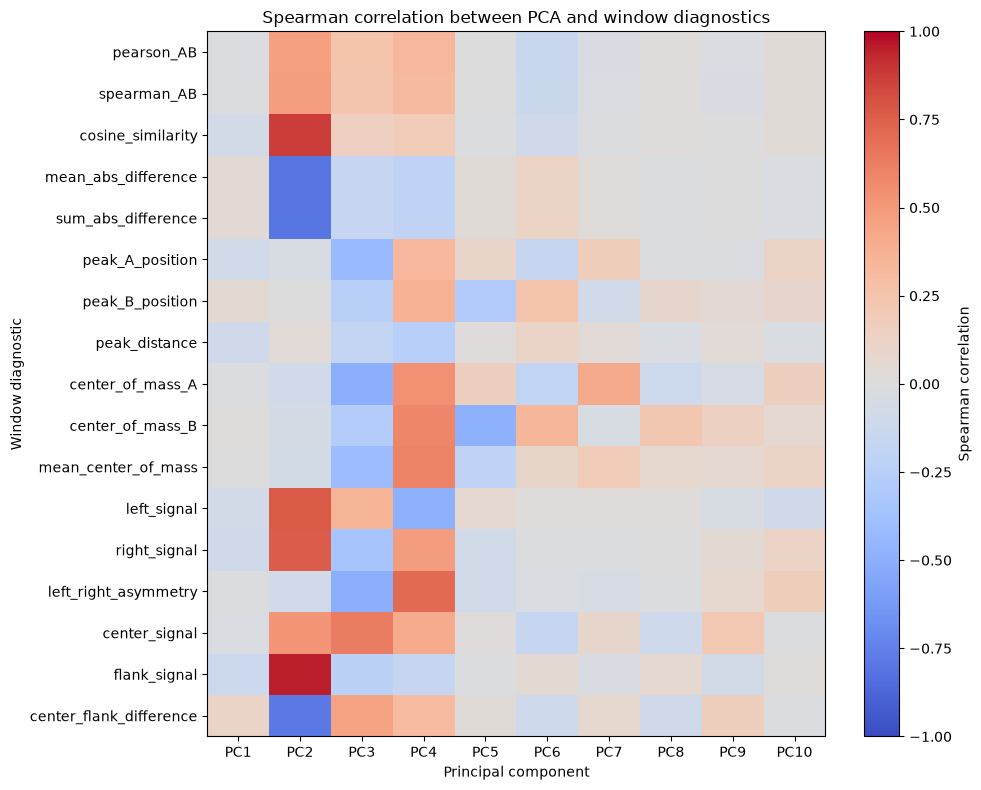

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

heatmap = ax.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(np.arange(len(pc_columns)))
ax.set_xticklabels(pc_columns)

ax.set_yticks(np.arange(len(diagnostic_columns)))
ax.set_yticklabels(diagnostic_columns)

ax.set_xlabel("Principal component")
ax.set_ylabel("Window diagnostic")
ax.set_title("Spearman correlation between PCA and window diagnostics")

fig.colorbar(heatmap, ax=ax, label="Spearman correlation")

plt.tight_layout()
plt.show()

In [27]:
for pc in pc_columns:
    strongest_metric = correlation_matrix[pc].abs().idxmax()
    correlation = correlation_matrix.loc[strongest_metric, pc]

    print(f"{pc}: {strongest_metric} ({correlation:.3f})")

PC1: flank_signal (-0.117)
PC2: flank_signal (0.945)
PC3: center_signal (0.628)
PC4: left_right_asymmetry (0.710)
PC5: center_of_mass_B (-0.488)
PC6: center_of_mass_B (0.338)
PC7: center_of_mass_A (0.412)
PC8: center_of_mass_B (0.226)
PC9: center_signal (0.214)
PC10: left_right_asymmetry (0.179)
